# Signal correlation between condition-averaged rate timelines

Do two units' **mean responses to a fixation have the same shape**, and does
that depend on what the animal was looking at?

## How this differs from the spike-coordination analysis

That analysis cross-correlates **per-fixation spike trains** and asks whether
two units fire together on the *same* fixation — **noise correlation**,
trial-by-trial covariation.

This one cross-correlates **condition-averaged rate timelines** and asks whether
their mean responses resemble each other, and at what lag — **signal
correlation**, shared tuning. Averaging over fixations removes trial-by-trial
covariation entirely, so nothing here is noise correlation. The two are
independent: a pair can share a response profile and be independent trial to
trial, or the reverse.

## Why the null has to be another unit

Every unit is fixation-locked, so every mean timeline has structure around
fixation onset and any two of them correlate before shared tuning is involved.
A null that only scrambles time would confirm that trivial structure rather than
test the interesting claim.

The null used instead is a **cross-session pairing**: unit A against a unit of
the same region recorded on a *different* session. That partner is
fixation-locked, real, and has been through the same pipeline, but shares no
session, array or behaviour with unit A.

## Why only selective units

A unit with no reliable fixation response has a mean timeline that is mostly
estimation noise, and correlating noise with noise adds variance and nothing
else. The default is the FDR-corrected selective set — which is also what makes
the question well posed: *do units that respond to fixation condition share
response shape* presumes units that respond.

Data is the combined ±500 ms, 10 ms-binned condition averages — the same export
the population PCA and the mRNN read, so the unit set is theirs by construction.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_signal_correlation as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

cfg = load_config(str(repo_root / "configs" / "dataset.yaml"))
settings = sc.SignalCorrelationSettings(cfg_path=str(repo_root / "configs" / "dataset.yaml"))
FIGURE_DIR = build_analysis_output_dir(cfg, sc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.SignalCorrelationPlotSettings(output_dir=FIGURE_DIR)
print("figures ->", FIGURE_DIR)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_signal_correlation/figures


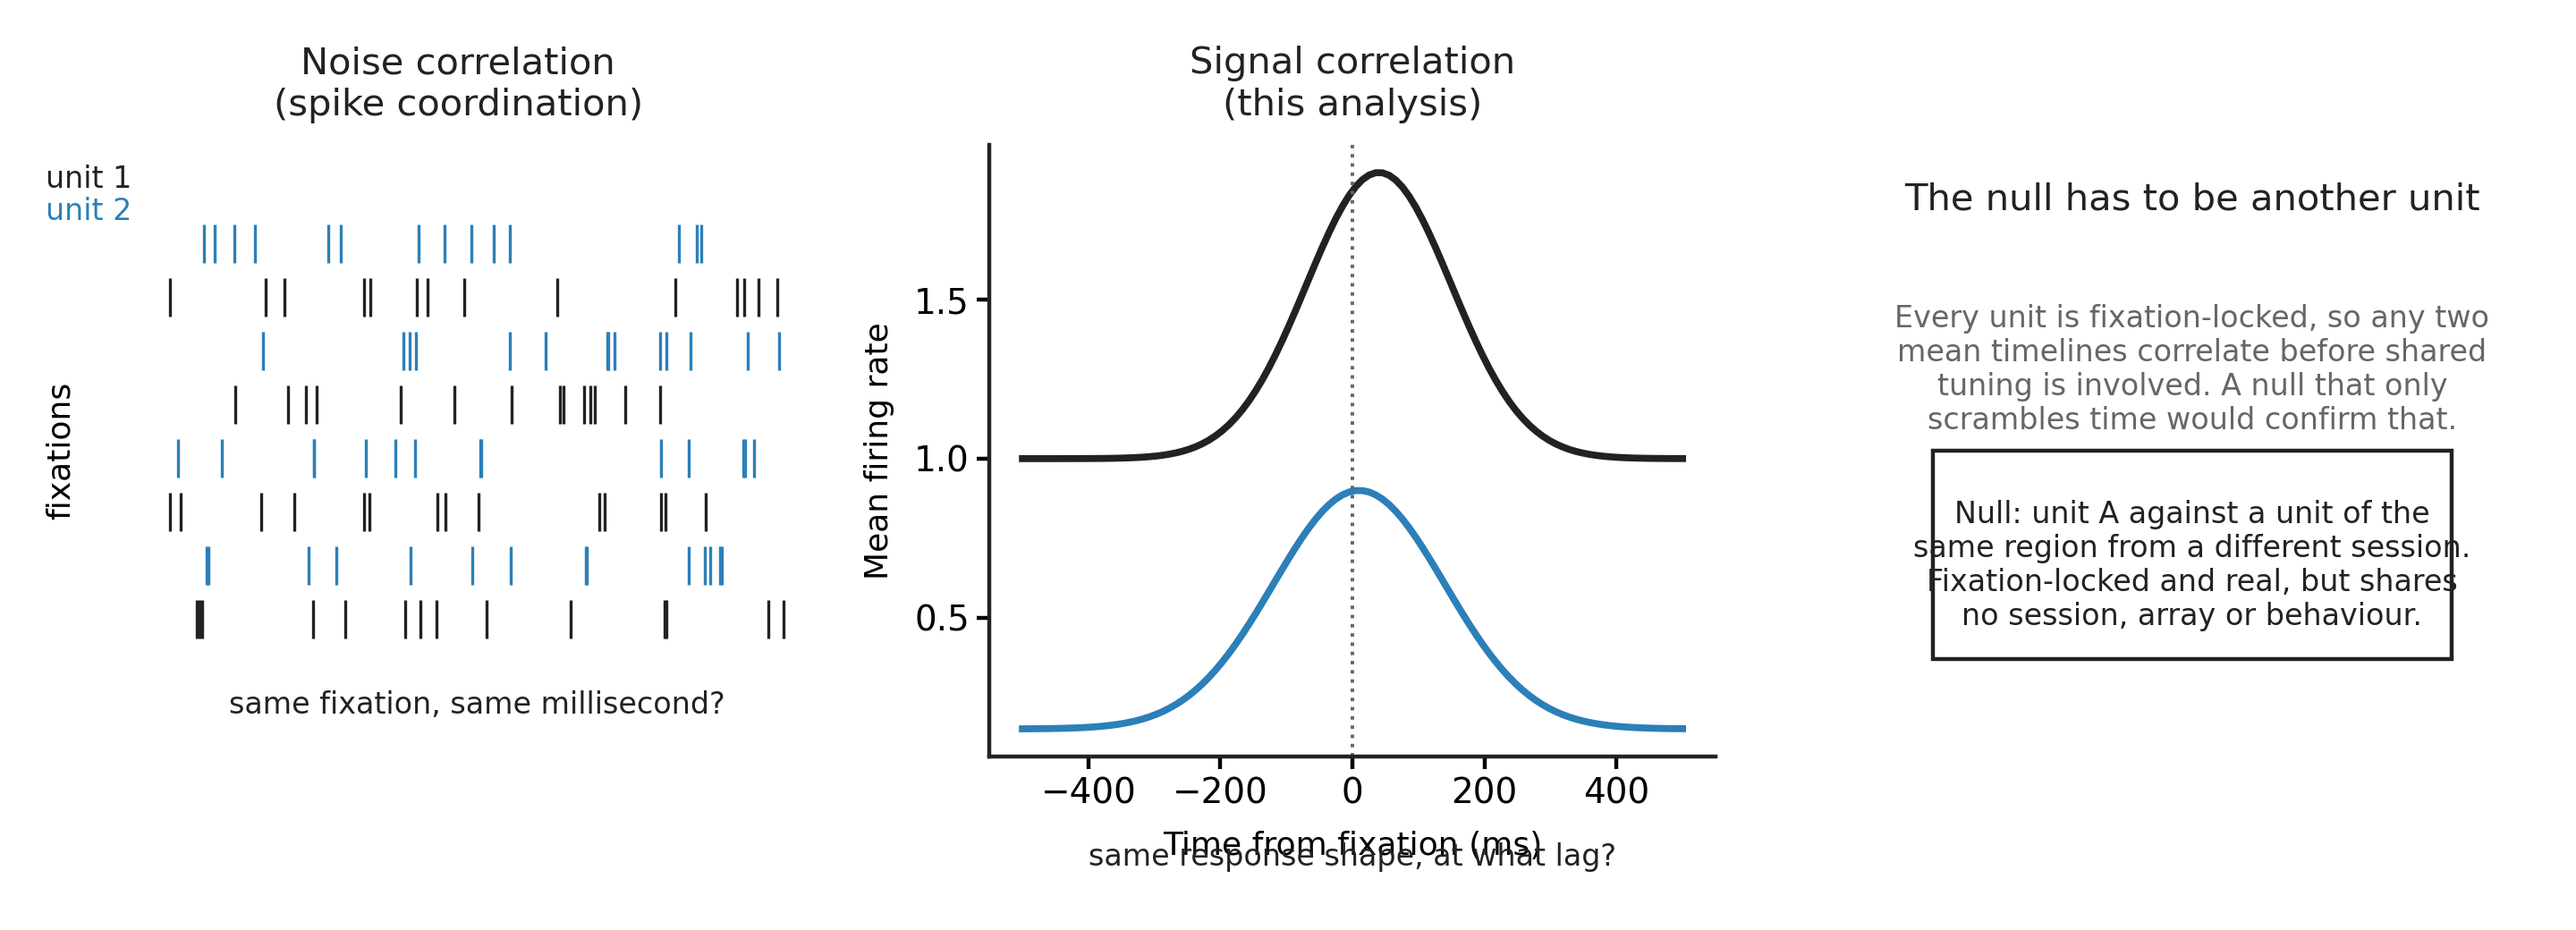

In [2]:
fig, paths = viz.plot_signal_vs_noise_schematic(figs)
display(Image(filename=str(paths["png"])))

## 1. What is in the analysis

In [3]:
units, timeline = sc.load_condition_timelines(settings)
print(f"selective units: {len(units)}   timeline: {timeline.size} bins, "
      f"{timeline.min()*1000:.0f} to {timeline.max()*1000:.0f} ms")
display(sc.build_unit_inventory(units))

pairs, lags_ms = sc.build_pair_correlations(units, timeline, settings)
print(f"pairs: {len(pairs):,}   lags: {lags_ms.size} "
      f"({lags_ms.min():.0f} to {lags_ms.max():.0f} ms)")
display(pairs.groupby(["scope", "region_pair"], observed=True).size().rename("n_pairs").to_frame())

selective units: 574   timeline: 100 bins, -495 to 495 ms


,region,n_units,n_dates
0,bla,287,35
1,accg,105,18
2,dmpfc,73,14
3,ofc,109,14


pairs: 5,206   lags: 51 (-250 to 250 ms)


n_pairs
scope         region_pair         
cross_region  accg-bla         752
              accg-dmpfc        43
              bla-dmpfc        847
              bla-ofc          559
within_region accg             356
              bla             1786
              dmpfc            320
              ofc              543

## 2. The correlation, and its null

Top row: the observed signal cross-correlation (solid) with the cross-session
null (dashed). Bottom row: the difference. A positive lag means unit 1 follows
unit 2, though for within-region pairs the ordering of the two units is
arbitrary so the sign carries no meaning there.

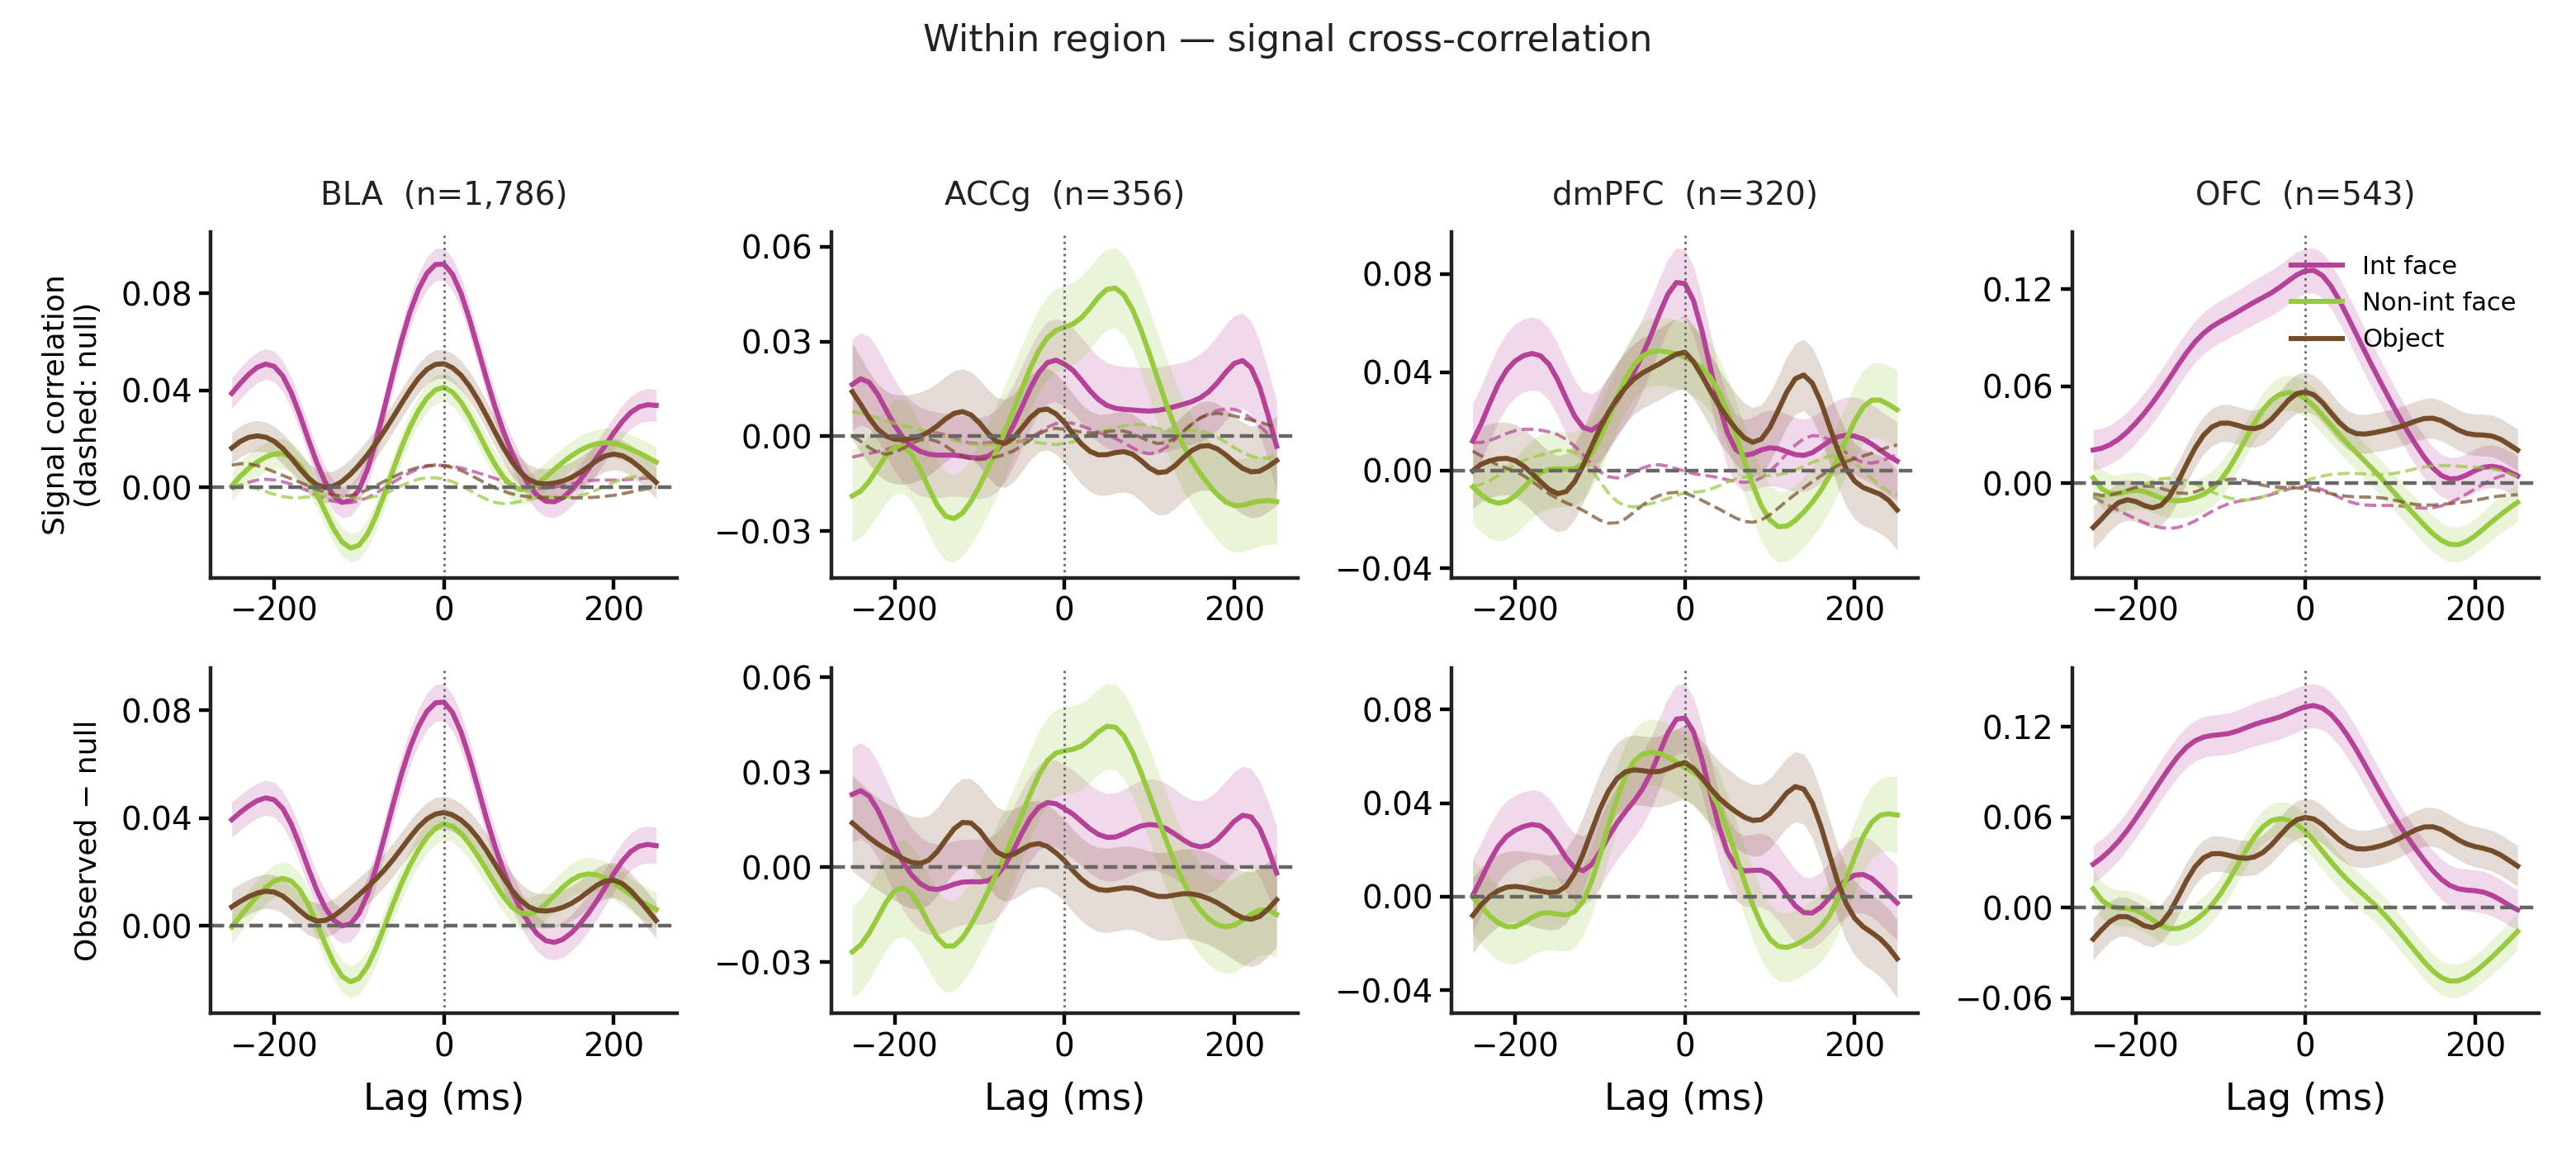

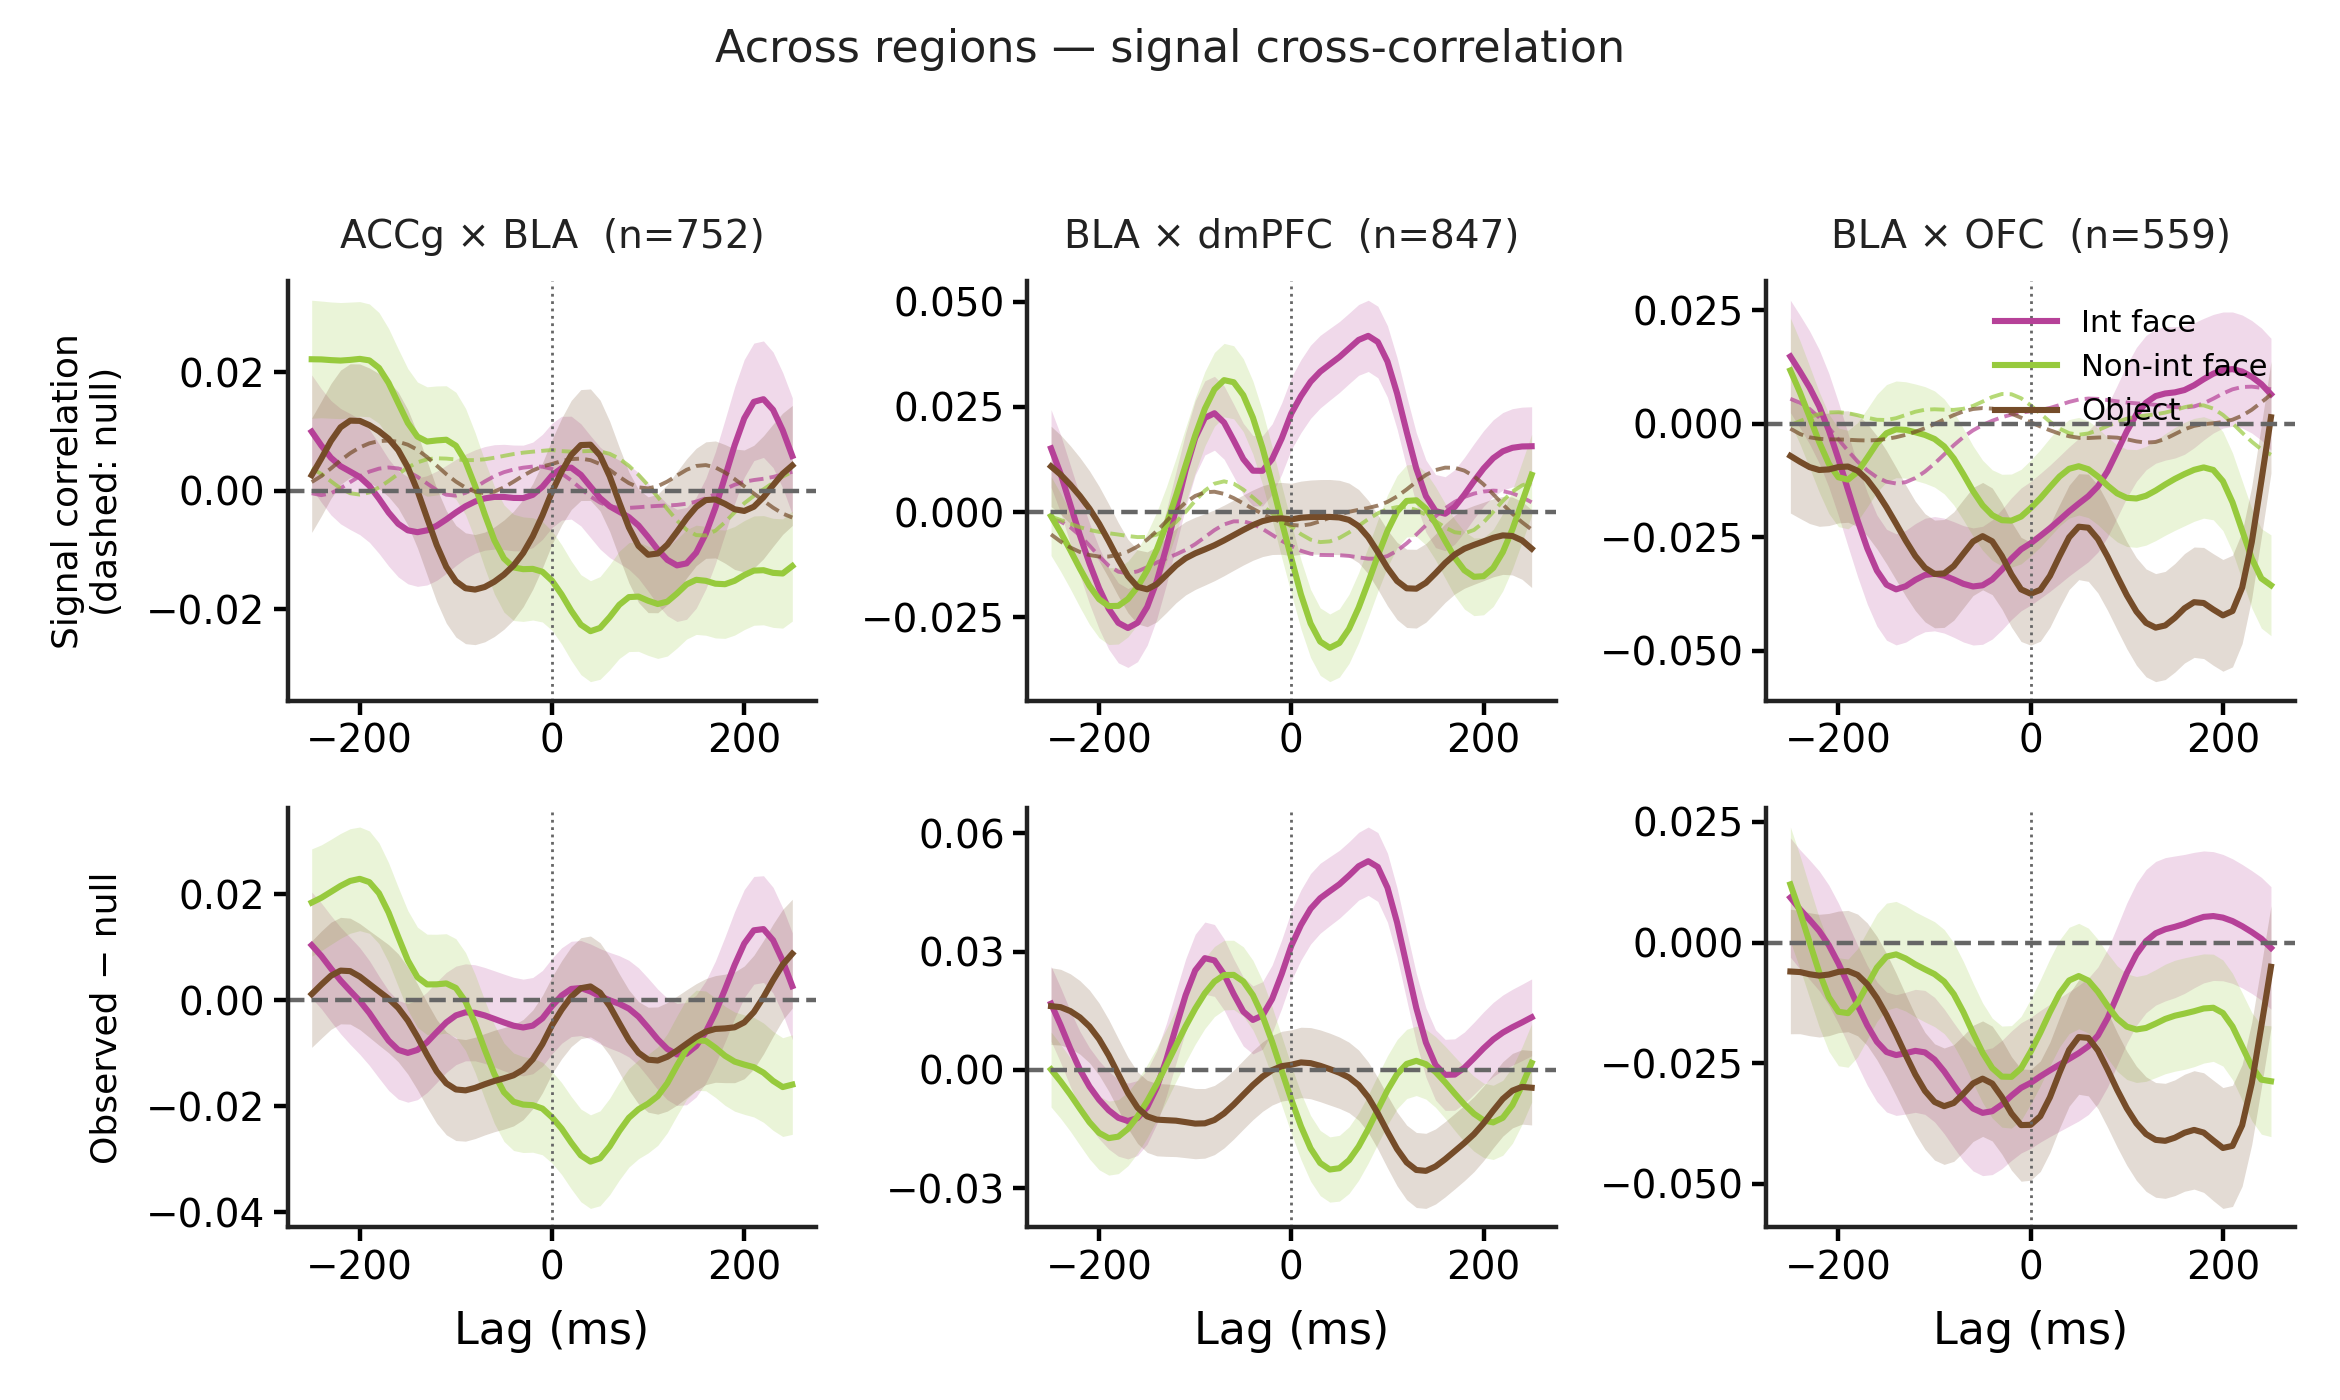

In [4]:
traces = sc.build_group_traces(pairs, settings)
for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_correlation_traces(traces, lags_ms, figs, scope=scope)
    display(Image(filename=str(paths["png"])))

## 3. Zero-lag summary and condition contrasts

Contrasts are paired within pair — the same two units contribute all three
conditions.

**Read the next section before interpreting these.**

,scope,region_pair,condition,n_pairs,mean,median,sem,frac_positive
0,cross_region,accg-bla,face_interactive,752,-0.0011,-0.0041,0.0090,0.4947
1,cross_region,accg-bla,face_non_interactive,752,-0.0221,-0.0219,0.0086,0.4681
2,cross_region,accg-bla,object,752,-0.0047,-0.0139,0.0091,0.4854
3,cross_region,bla-dmpfc,face_interactive,847,0.0315,0.0339,0.0088,0.5490
4,cross_region,bla-dmpfc,face_non_interactive,847,-0.0075,-0.0079,0.0086,0.4852
5,cross_region,bla-dmpfc,object,847,0.0013,0.0031,0.0089,0.5030
6,cross_region,bla-ofc,face_interactive,559,-0.0291,-0.0448,0.0136,0.4419
7,cross_region,bla-ofc,face_non_interactive,559,-0.0226,-0.0082,0.0109,0.4848
8,cross_region,bla-ofc,object,559,-0.0378,-0.0222,0.0115,0.4562
9,within_region,accg,face_interactive,356,0.0185,0.0341,0.0139,0.5421


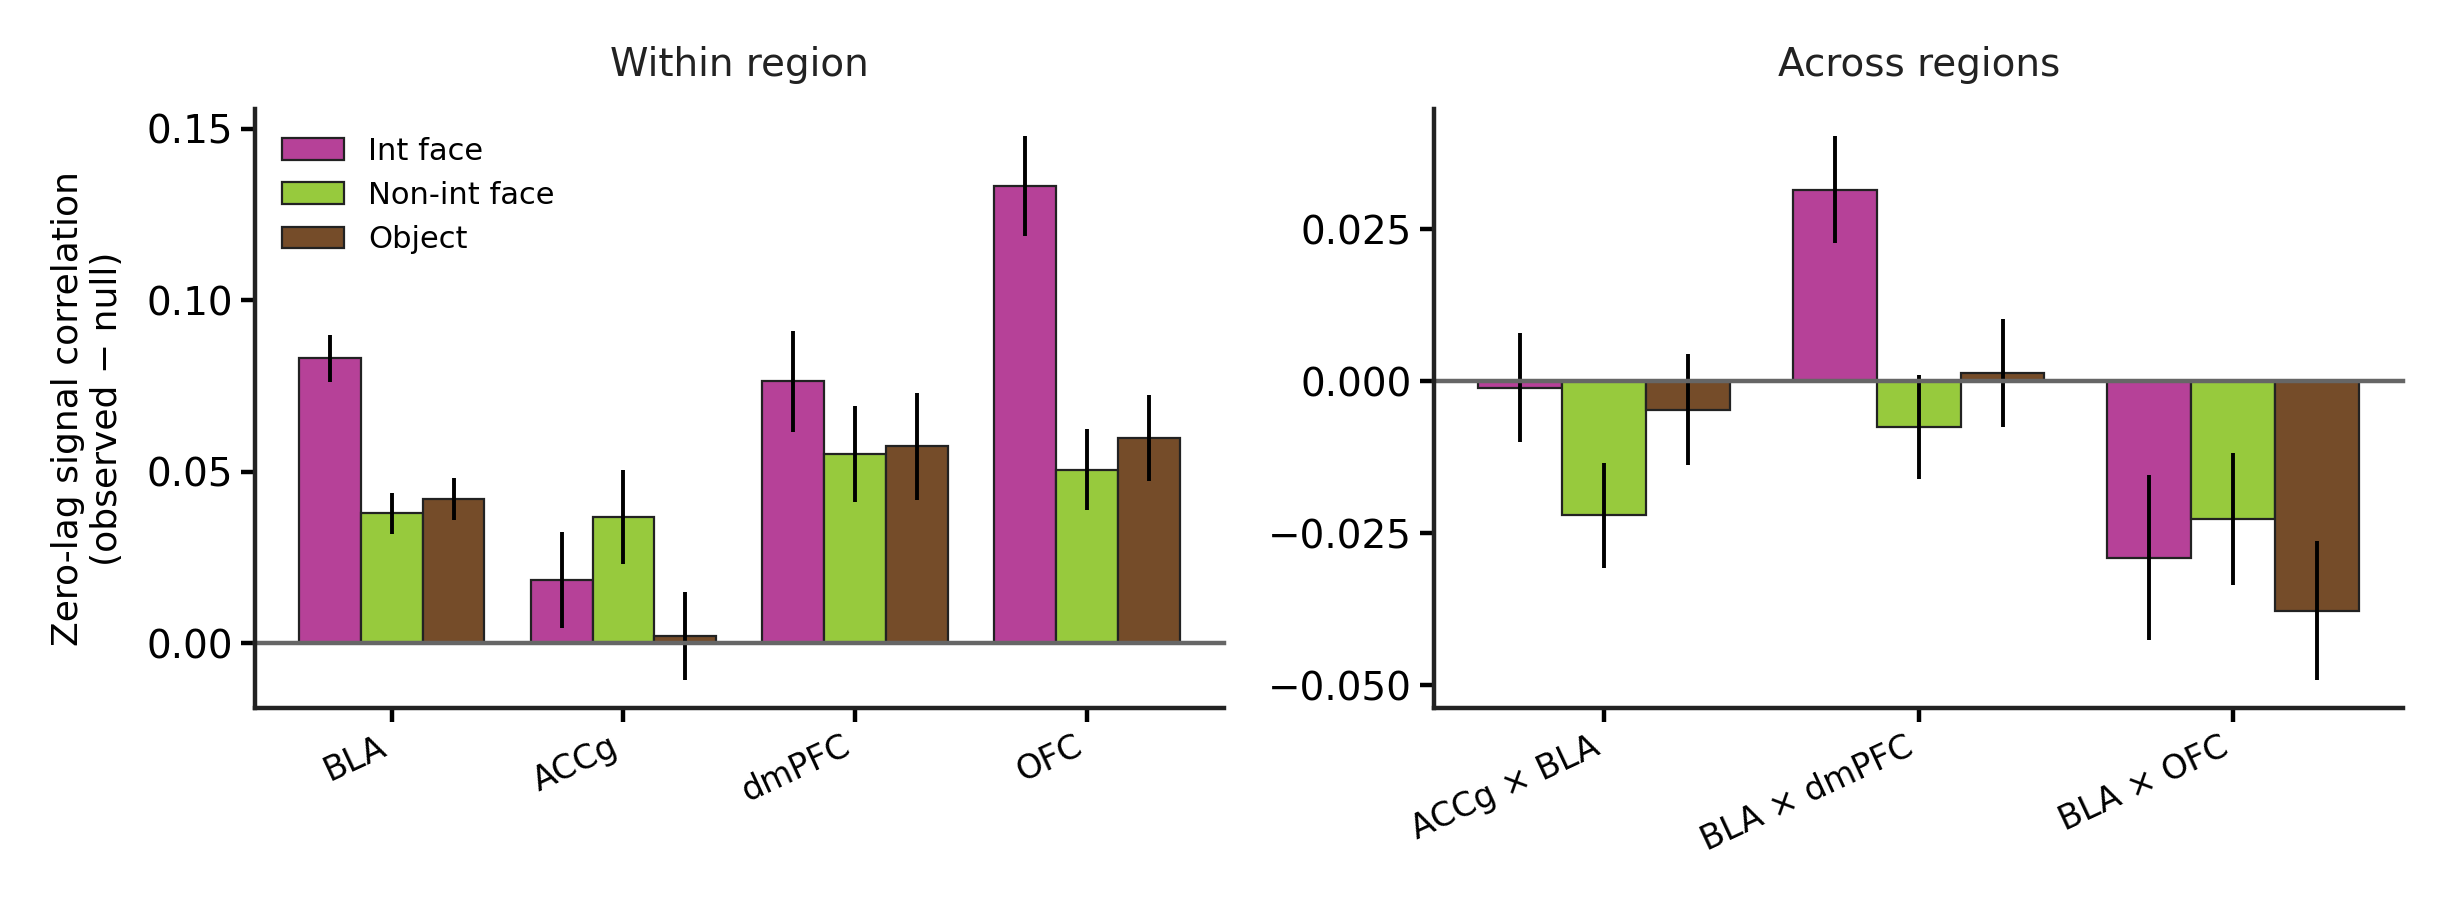

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,p_value,effect_size_rank_biserial,p_value_corrected,significant
0,cross_region,accg-bla,face_interactive,face_non_interactive,752,-0.0011,-0.0221,0.0210,0.0857,0.0399,0.2251,False
1,cross_region,accg-bla,face_interactive,object,752,-0.0011,-0.0047,0.0036,0.6176,0.0000,0.7770,False
2,cross_region,accg-bla,face_non_interactive,object,752,-0.0221,-0.0047,-0.0174,0.3616,0.0027,0.5922,False
3,cross_region,bla-dmpfc,face_interactive,face_non_interactive,847,0.0315,-0.0075,0.0390,0.0025,0.0626,0.0104,True
4,cross_region,bla-dmpfc,face_interactive,object,847,0.0315,0.0013,0.0302,0.0082,0.0815,0.0288,True
5,cross_region,bla-dmpfc,face_non_interactive,object,847,-0.0075,0.0013,-0.0088,0.7540,-0.0177,0.8026,False
6,cross_region,bla-ofc,face_interactive,face_non_interactive,559,-0.0291,-0.0226,-0.0065,0.6660,0.0161,0.7770,False
7,cross_region,bla-ofc,face_interactive,object,559,-0.0291,-0.0378,0.0087,0.7644,-0.0161,0.8026,False
8,cross_region,bla-ofc,face_non_interactive,object,559,-0.0226,-0.0378,0.0152,0.3983,0.0304,0.5922,False
9,within_region,accg,face_interactive,face_non_interactive,356,0.0185,0.0368,-0.0183,0.2343,-0.0730,0.5195,False


In [5]:
summary = sc.summarize_signal_correlation(pairs, settings)
display(summary.round(4))

fig, paths = viz.plot_condition_summary(summary, figs)
display(Image(filename=str(paths["png"])))

contrasts = sc.compare_conditions(pairs, settings)
display(contrasts.round(4))

## 4. The confound that decides this analysis

A mean timeline estimated from 168 fixations is noisier than one from 1169, and
a correlation between two noisy estimates is attenuated towards zero.
Interactive-face fixations outnumber the others roughly six to one, so
interactive-face timelines are the cleanest of the three and will correlate best
with anything — including with each other.

The cross-session null does **not** absorb this: the null partner shares no
tuning, so its correlation sits near zero whatever the trial count. Reliability
lifts the observed correlation between genuinely similar units without lifting
the null by anything comparable.

Spearman's correction for attenuation is the textbook remedy and is **not usable
here**, for a reason worth stating rather than hiding:

In [6]:
rows = []
for condition in settings.conditions:
    rows.append({
        "condition": condition,
        "median_n_trials": float(np.nanmedian(pairs[f"{condition}_n_trials_1"])),
        "mean_reliability_estimate": float(np.nanmean(pairs[f"{condition}_reliability_1"])),
    })
display(pd.DataFrame(rows).round(3))
display(Markdown(
    "The reliability estimates are **negative**, which is why no attenuation "
    "correction is applied: these timelines are smoothed before averaging while "
    "the SEMs are not correspondingly reduced, so the textbook correction would "
    "divide by the square root of a negative number. Stratification is used "
    "instead."
))

,condition,median_n_trials,mean_reliability_estimate
0,face_interactive,1169.0,-0.176
1,face_non_interactive,168.0,-0.314
2,object,199.0,-0.241


The reliability estimates are **negative**, which is why no attenuation correction is applied: these timelines are smoothed before averaging while the SEMs are not correspondingly reduced, so the textbook correction would divide by the square root of a negative number. Stratification is used instead.

### Stratification instead

The ratio of interactive-face to object trial counts ranges from about 1 to 16
across pairs, so the comparison can be repeated inside strata of that ratio.

- **shared tuning** predicts a difference that is flat across strata
- **estimation noise** predicts one that grows with the ratio and vanishes as it approaches one

This is the figure the conclusion rests on.

,ratio_stratum,n_pairs,median_trial_ratio,face_interactive,face_non_interactive,object,face_interactive_minus_object,p_value,effect_size_rank_biserial
0,"(0.96, 3.064]",1935,1.5590,0.0129,0.0071,0.0088,0.0041,0.5281,0.0171
1,"(3.064, 4.66]",699,4.1314,0.0655,0.0292,0.0526,0.0129,0.3302,0.0415
2,"(4.66, 8.833]",1581,7.2165,0.0796,0.0224,0.0135,0.0661,0.0000,0.1322
3,"(8.833, 16.164]",991,10.1053,0.0653,0.0211,0.0293,0.0361,0.0004,0.1261


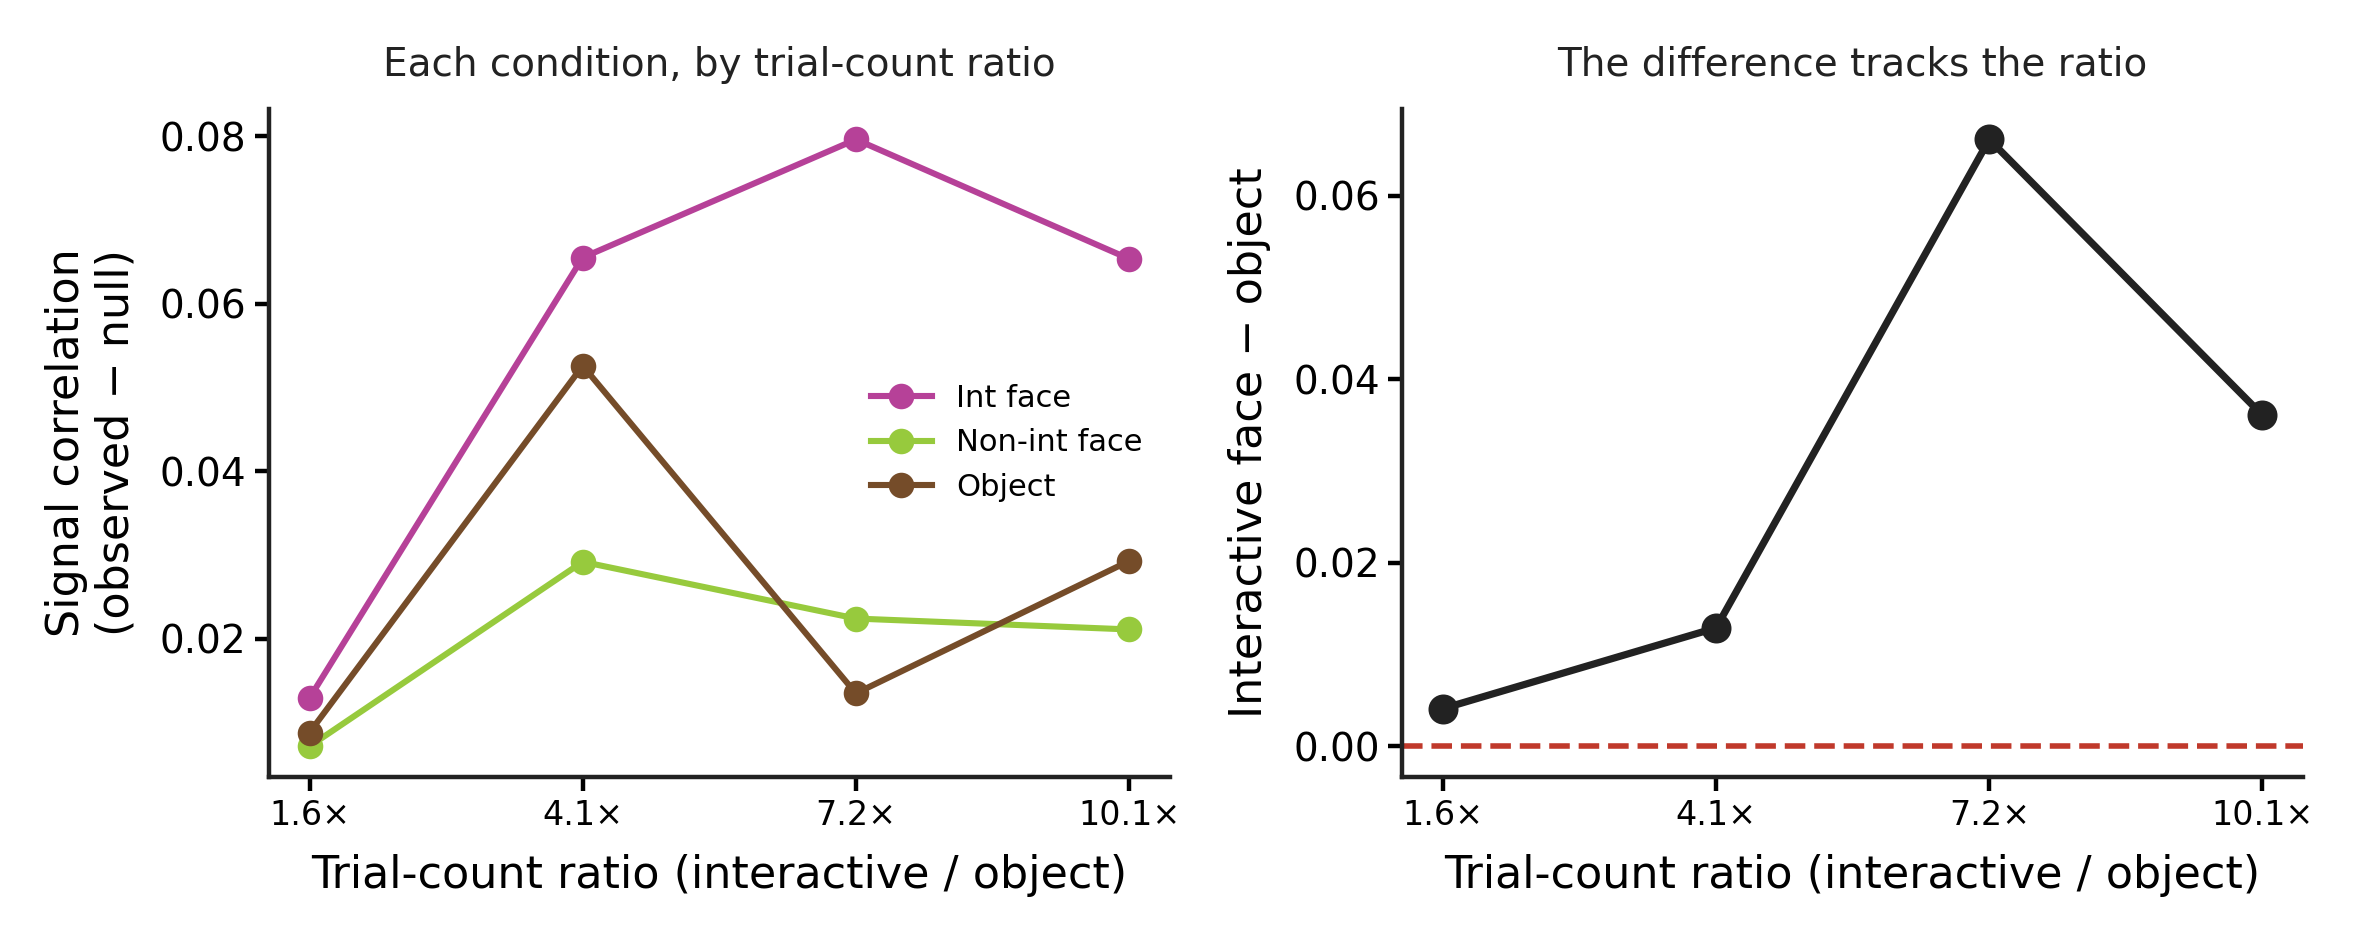

In [7]:
strata = sc.stratify_by_trial_ratio(pairs, settings)
display(strata.round(4))

fig, paths = viz.plot_trial_count_confound(strata, figs)
display(Image(filename=str(paths["png"])))

## 5. Does signal correlation track noise correlation?

The two are different quantities and need not be related. Matching each pair to
its spike-coordination measurement lets the question be asked directly — and
only the two analyses together can answer it.

/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/analysis/fixation_signal_correlation.py:630: PerformanceWarning: indexing past lexsort depth may impact performance.
  if key not in lookup.index:
/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/analysis/fixation_signal_correlation.py:632: PerformanceWarning: indexing past lexsort depth may impact performance.
  value = lookup.loc[key]


pairs matched to a spike-coordination measurement: 9,301


,scope,region_pair,condition,n_pairs,spearman_rho,p_value
0,cross_region,accg-bla,face_interactive,251,-0.0237,0.7090
1,cross_region,accg-bla,face_non_interactive,249,-0.0545,0.3921
2,cross_region,accg-bla,object,251,-0.0869,0.1700
3,within_region,accg,face_interactive,354,-0.0007,0.9888
4,within_region,accg,face_non_interactive,325,0.0008,0.9883
5,within_region,accg,object,351,0.1279,0.0165
6,within_region,bla,face_interactive,1714,0.1237,0.0000
7,within_region,bla,face_non_interactive,1656,0.0199,0.4178
8,within_region,bla,object,1617,0.0571,0.0217
9,within_region,dmpfc,face_interactive,320,0.0969,0.0834


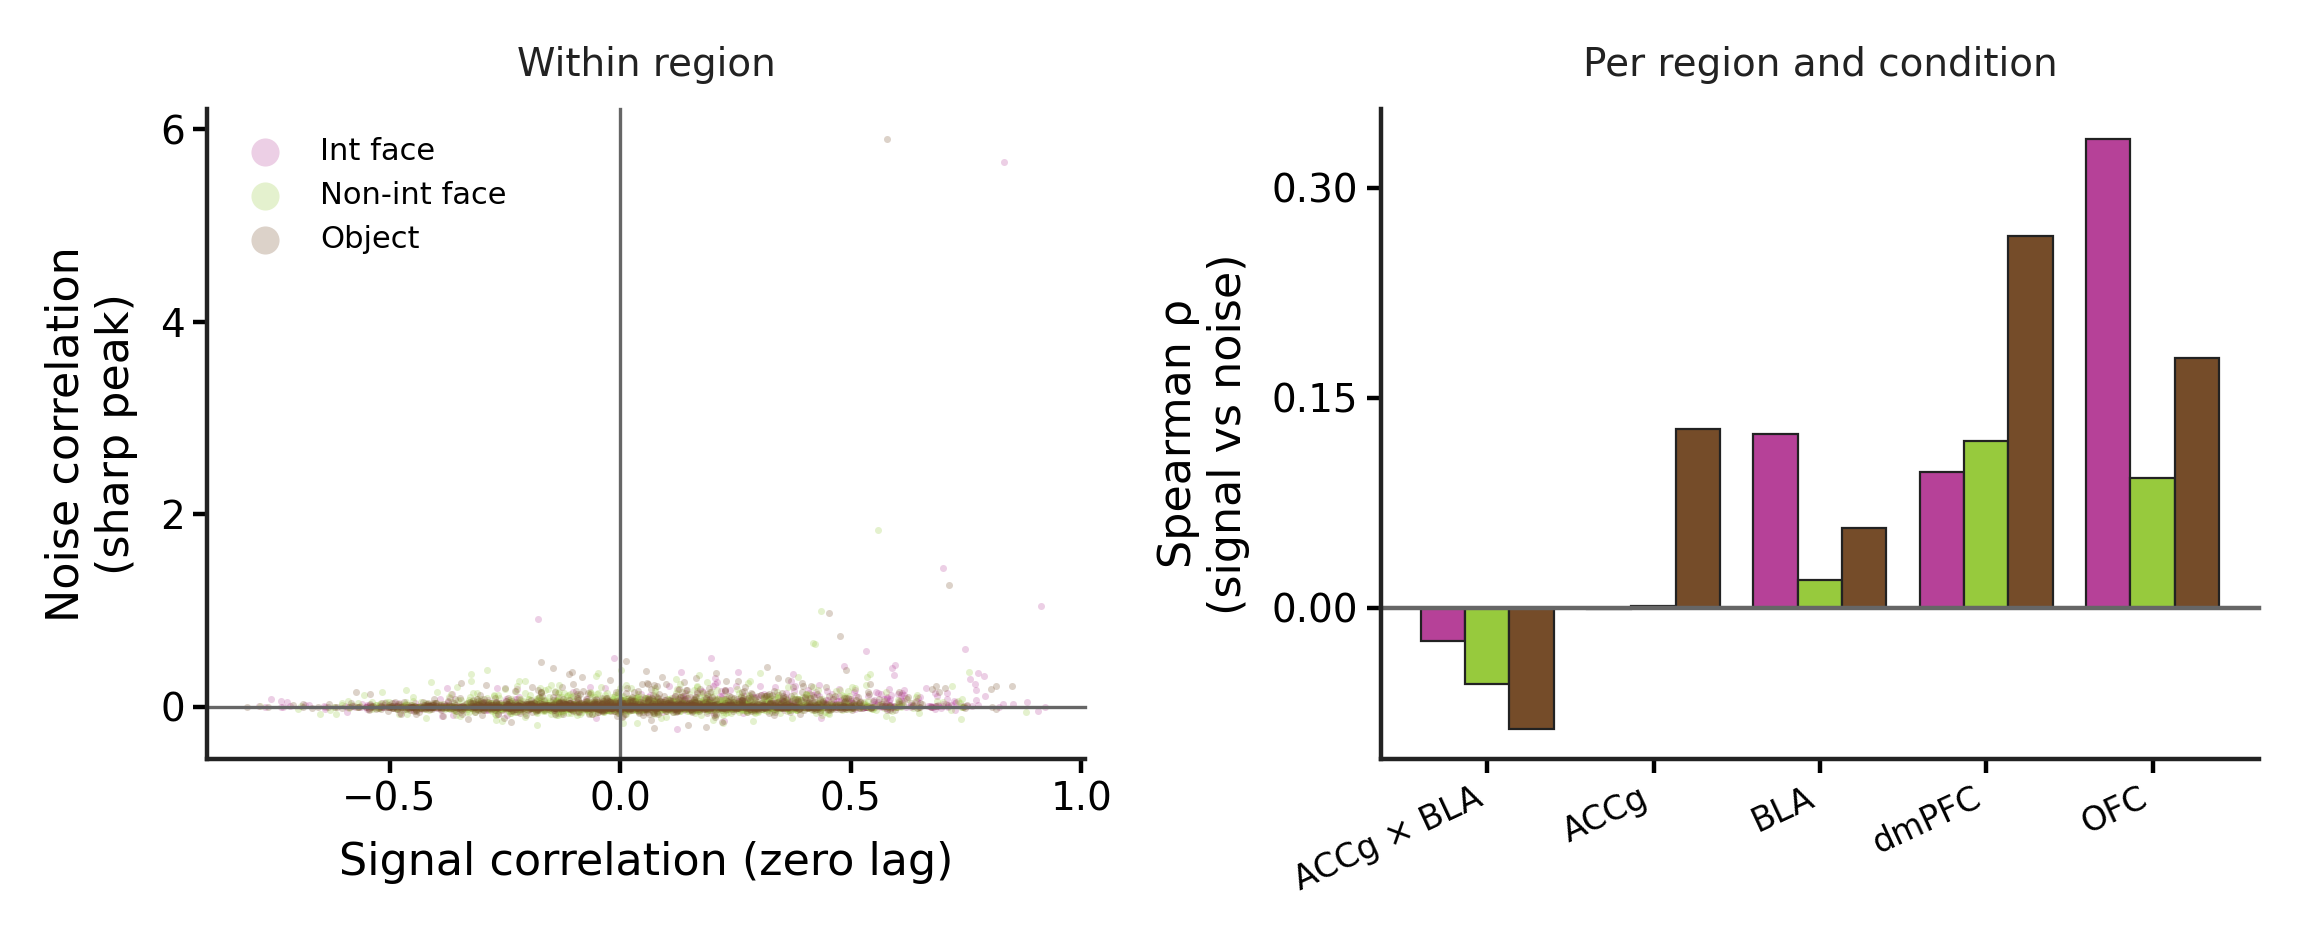

In [8]:
joined = sc.join_with_noise_correlation(pairs, settings)
print(f"pairs matched to a spike-coordination measurement: {len(joined):,}")

correlations = sc.correlate_signal_with_noise(joined)
display(correlations.round(4))

fig, paths = viz.plot_signal_vs_noise(joined, correlations, figs)
display(Image(filename=str(paths["png"])))

## What to take from this

Fill in against the numbers above, but the shape of the answer is:

1. **Signal correlation is clearly above the cross-session null** within region —
   units recorded together resemble each other more than units of the same
   region recorded apart.
2. **The apparent interactive-face advantage does not survive the trial-count
   control.** Check the lowest-ratio stratum in section 4: if the difference is
   near zero there and grows with the ratio, the effect is estimation noise.
3. **Signal and noise correlation are positively related within region**, which
   is a real link between this notebook and the spike-coordination one.

### Caveats

1. Trial-count imbalance is the dominant methodological problem here, and the
   stratification only controls it — it does not remove it. A properly matched
   comparison would need the per-trial data re-averaged at matched counts.
2. Cross-region pairs are far fewer and noisier; treat those panels as weak.
3. The reliability estimate is negative for most units because the timelines are
   smoothed. It is reported as a diagnostic, not used.